# Project 1 – Exercise 1: Enzyme Kinetics (Michaelis-Menten)
**Batch reactor design and operation**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12

## Part (b) – Full ODE System

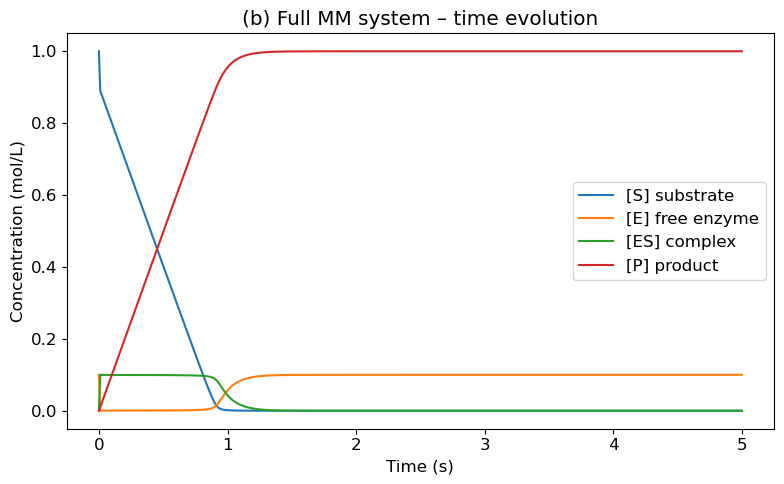

In [ ]:
kf   = 1e4   # L/(mol·s)
kb  = 20.0   # 1/s  (k_b)
kcat = 10.0   # 1/s

# Initial concentrations  [mol/L]
S0  = 1.0
E0  = 0.1
P0  = 0.0
ES0 = 0.0

t_span = (0, 5)       # seconds
t_eval = np.linspace(0, 5, 500)

# ODE system
def ode_full(t, y, kf, kb, kcat):
    S, E, ES, P = y
    dS  = -kf*S*E + kb*ES
    dE  = -kf*S*E + kb*ES + kcat*ES
    dES =  kf*S*E - kb*ES - kcat*ES
    dP  =  kcat*ES
    return [dS, dE, dES, dP]

y0_full = [S0, E0, ES0, P0]
sol_full = solve_ivp(ode_full, t_span, y0_full, args=(kf, kb, kcat),
                     t_eval=t_eval, method='Radau', rtol=1e-8, atol=1e-10)

S_f, E_f, ES_f, P_f = sol_full.y

# Plot
fig, ax = plt.subplots()
ax.plot(sol_full.t, S_f,  label='[S] substrate')
ax.plot(sol_full.t, E_f,  label='[E] free enzyme')
ax.plot(sol_full.t, ES_f, label='[ES] complex')
ax.plot(sol_full.t, P_f,  label='[P] product')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Concentration (mol/L)')
ax.set_title('(b) Full MM system - time evolution')
ax.legend()
plt.tight_layout()
plt.savefig('b_full_ode.png', dpi=150)
plt.show()

## Part (c) – Quasi-Steady State Approximation (QSSA)

Setting $d[ES]/dt = 0$:
$$k_1[S][E] = (k_b + k_{cat})[ES]$$

Using enzyme conservation $[E] = [E_0] - [ES]$:
$$k_f[S]([E_0] - [ES]) = (k_b+k_{cat})[ES]$$
$$[ES] = \frac{[E_0][S]}{K_M + [S]}, \quad K_M = \frac{k_b+k_{cat}}{k_f}$$

The Michaelis constant for our parameters:
$$K_M = \frac{20+10}{10} = 0.3 \text{ mmol/L}$$

In [26]:
KM = ((kb + kcat) / kf)  
print(f'K_M = {KM:.3f} mol/L')

K_M = 0.003 mol/L


## Part (d) – QSSA ODE System

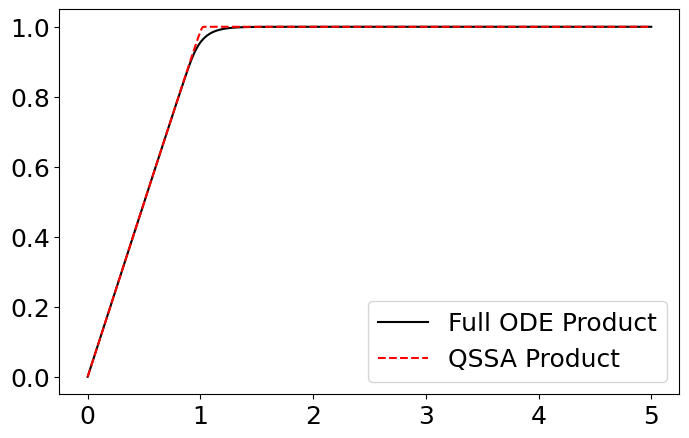

In [ ]:
# ODE system under QSSA
def ode_qssa(t, y, kcat, KM, E0 ):
    S, P = y
    ES = (E0 * S )/ (KM + S)
    dS = -kcat*ES
    dP =  kcat*ES
    return [dS, dP]

y0_qssa = [S0, P0]
sol_qssa = solve_ivp(ode_qssa, t_span, y0_qssa, args=(kcat, KM, E0),
                     t_eval=t_eval, method='BDF', rtol=1e-8, atol=1e-10)

S_q, P_q = sol_qssa.y

sol_qssa = solve_ivp(ode_qssa, t_span, [S0, 0], args=(kcat, KM, E0),
                     t_eval=t_eval, method='BDF')

# 3. Plot Comparison
plt.plot(sol_full.t, sol_full.y[3], 'k-', label='Full ODE Product')
plt.plot(sol_qssa.t, sol_qssa.y[1], 'r--', label='QSSA Product')
plt.legend()
plt.show()

## Part (e) – Initial Rate v(t=0) as a function of parameters

QSSA validity requires $[E_0] \ll [S_0]$, so we scan $[E_0]$ in $[0.0001, 0.1]$ mol/L.

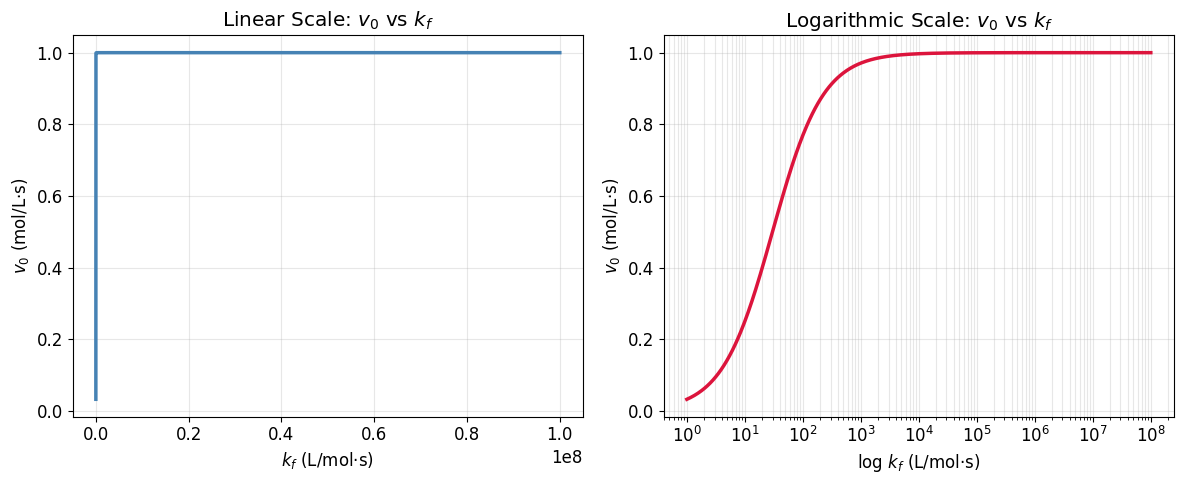

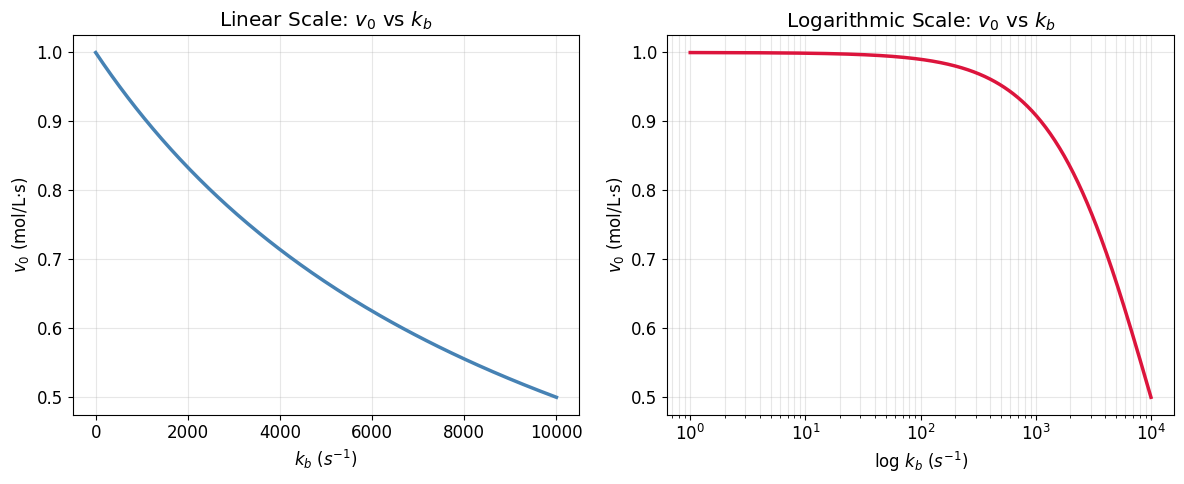

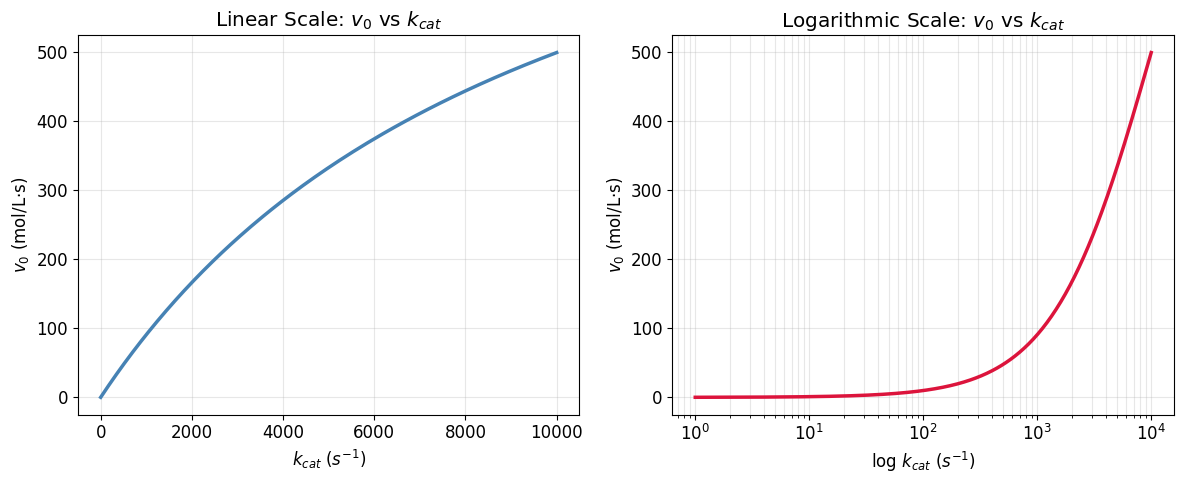

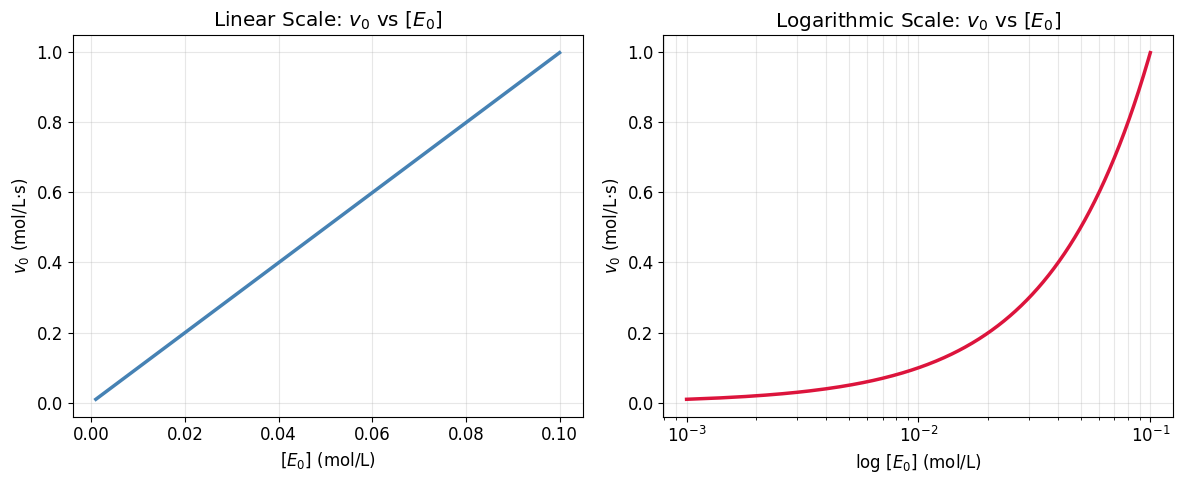

In [ ]:
S0 = 1.0           # mol/L
E0_def = 0.1       # mol/L
kf_def = 1e4       # L/(mol·s)
kb_def = 20.0      # s^-1
kcat_def = 10.0    # s^-1

# Define Parameter Ranges
kf_range = np.logspace(0, 8, 500) # 1 to 10^8
kb_range = np.logspace(0, 4, 500) # 1 to 10^4
kcat_range = np.logspace(0, 4, 500) # 1 to 10^4
E0_range = np.linspace(0.001, 0.1, 500) # 0.001 to 0.1 mol/L

# Rate function
def calculate_v0(E0, S0, kf, kb, kcat):
    KM = (kb + kcat) / kf
    v_max = kcat * E0
    return (v_max * S0) / (KM + S0)

# Plot
def plot_dual_sensitivity(param_name, p_range, label, units, kf=kf_def, kb=kb_def, kcat=kcat_def, E0=E0_def):
    v0_vals = []
    for p in p_range:
        if param_name == 'kf':
            v0_vals.append(calculate_v0(E0, S0, p, kb, kcat))
        elif param_name == 'kb':
            v0_vals.append(calculate_v0(E0, S0, kf, p, kcat))
        elif param_name == 'kcat':
            v0_vals.append(calculate_v0(E0, S0, kf, kb, p))
        elif param_name == 'E0':
            v0_vals.append(calculate_v0(p, S0, kf, kb, kcat))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Linear Plot
    ax1.plot(p_range, v0_vals, color='steelblue', lw=2.5)
    ax1.set_title(f'Linear Scale: $v_0$ vs {label}')
    ax1.set_xlabel(f'{label} ({units})')
    ax1.set_ylabel('$v_0$ (mol/L·s)')
    ax1.grid(True, alpha=0.3)

    # Logarithmic Plot
    ax2.plot(p_range, v0_vals, color='crimson', lw=2.5)
    ax2.set_xscale('log')
    ax2.set_title(f'Logarithmic Scale: $v_0$ vs {label}')
    ax2.set_xlabel(f'log {label} ({units})')
    ax2.set_ylabel('$v_0$ (mol/L·s)')
    ax2.grid(True, which="both", alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'sensitivity_{param_name}.png', dpi=150)
    plt.show()

plot_dual_sensitivity('kf', kf_range, '$k_f$', 'L/mol·s')
plot_dual_sensitivity('kb', kb_range, '$k_b$', '$s^{-1}$')
plot_dual_sensitivity('kcat', kcat_range, '$k_{cat}$', '$s^{-1}$')
plot_dual_sensitivity('E0', E0_range, '$[E_0]$', 'mol/L')

## Part (f) – Scaled Sensitivity Analysis

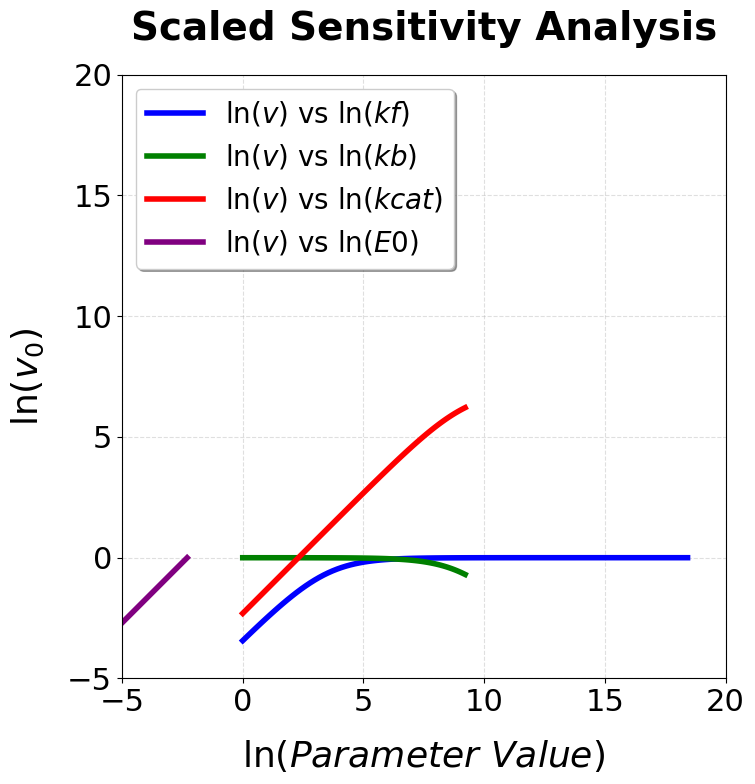

In [ ]:
S0 = 1.0        # mol/L
E0_ref = 0.1    # mol/L
kf_ref, kb_ref, kcat_ref = 1e4, 20.0, 10.0    # L/(mol·s), 1/s, 1/s

# Ranges
kf_range = np.logspace(0, 8, 100)
kb_range = np.logspace(0, 4, 100)
kcat_range = np.logspace(0, 4, 100)
E0_range = np.linspace(0.001, 0.1, 100)

# Rate function
def calculate_v0(kf, kb, kcat, E0, S=S0):
    KM = (kb + kcat) / kf
    v_max = kcat * E0
    return (v_max * S) / (KM + S)


def get_log_data(param_name, param_range):
    ln_v = []
    for p in param_range:
        if param_name == 'kf':   v = calculate_v0(p, kb_ref, kcat_ref, E0_ref)
        elif param_name == 'kb': v = calculate_v0(kf_ref, p, kcat_ref, E0_ref)
        elif param_name == 'kcat':v = calculate_v0(kf_ref, kb_ref, p, E0_ref)
        elif param_name == 'E0':  v = calculate_v0(kf_ref, kb_ref, kcat_ref, p)
        ln_v.append(np.log(v))
    return np.log(param_range), np.array(ln_v)

# Plot
plt.figure(figsize=(10, 8))

for name, rng, color in [('kf', kf_range, 'blue'), ('kb', kb_range, 'green'), 
                         ('kcat', kcat_range, 'red'), ('E0', E0_range, 'purple')]:
    ln_p, ln_v = get_log_data(name, rng)
    plt.plot(ln_p, ln_v, label=rf'$\ln(v)$ vs $\ln({name})$', color=color, lw=4)

# Axis limits
plt.xlim(-5, 20)
plt.ylim(-5, 20)

# Boosting label and title sizes
plt.xlabel(r'$\ln(\mathit{Parameter \ Value})$', fontsize=26, labelpad=15)
plt.ylabel(r'$\ln(v_0)$', fontsize=26, labelpad=15)
plt.title('Scaled Sensitivity Analysis', fontsize=28, fontweight='bold', pad=25)

# Boosting legend size
plt.legend(fontsize=20, loc='upper left', frameon=True, shadow=True)

# Boosting axis number sizes
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)

plt.grid(True, alpha=0.4, linestyle='--')
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

C:\Users\Anders Eggen\AppData\Local\Temp\ipykernel_34984\2497171898.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(fontsize=18, loc='upper left', frameon=True, shadow=True)


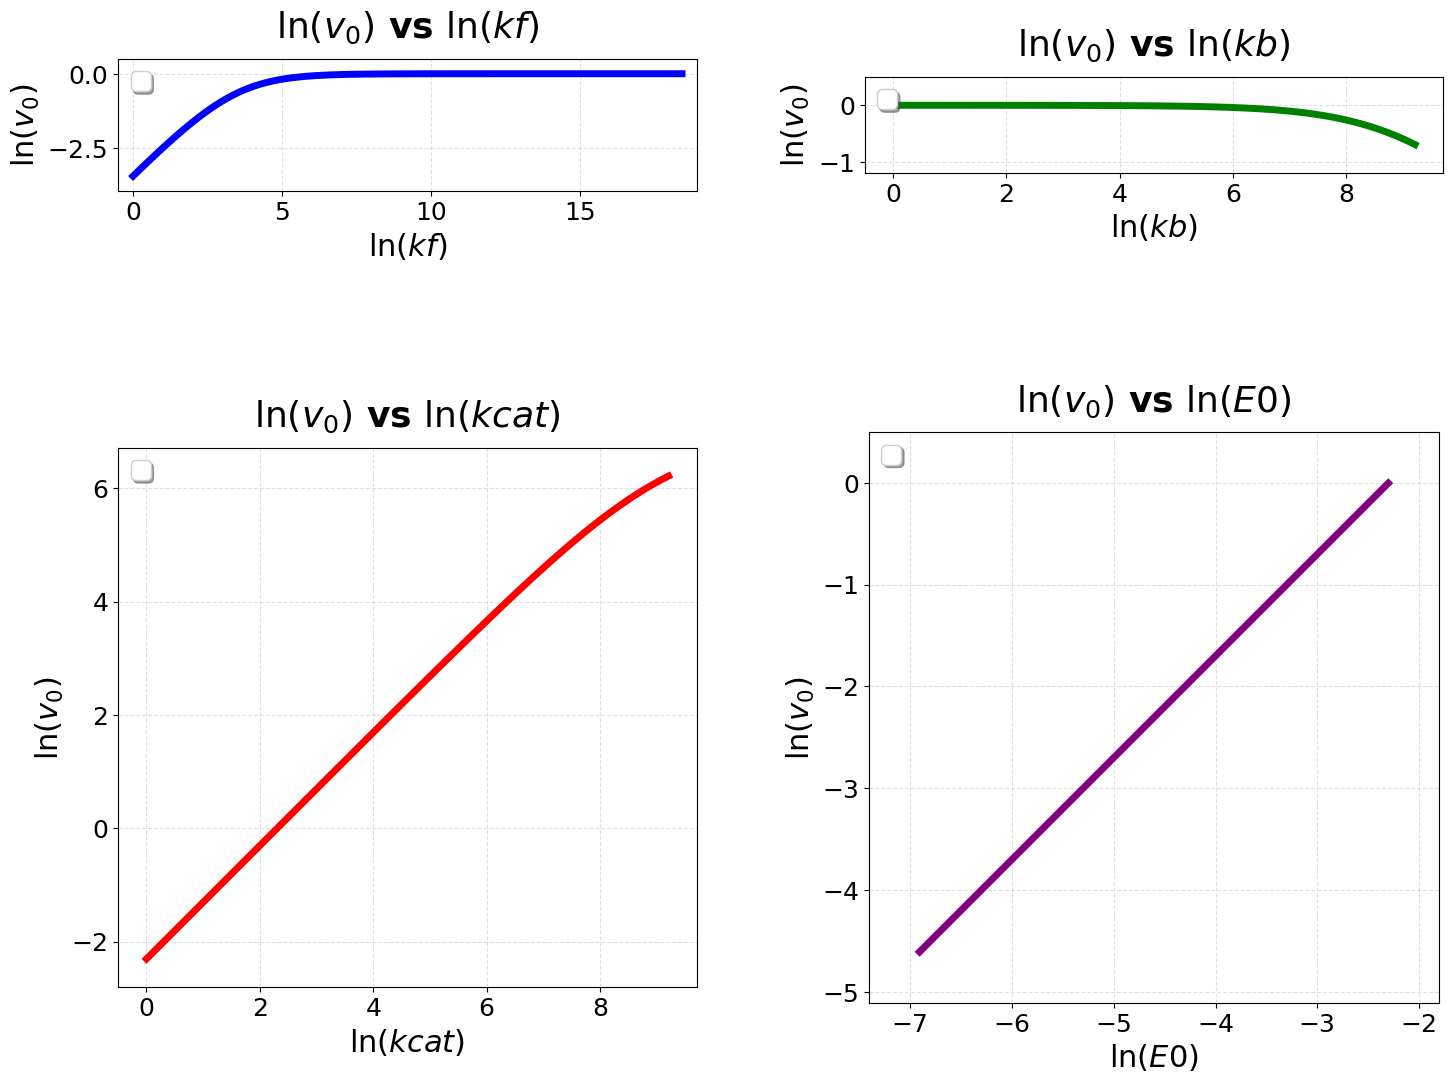

In [ ]:

# Individual plotting of the sensitivity for each parameter
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

params_list = [
    ('kf', kf_range, 'blue'),
    ('kb', kb_range, 'green'),
    ('kcat', kcat_range, 'red'),
    ('E0', E0_range, 'purple')
]

ref_params = {'kf': kf_ref, 'kb': kb_ref, 'kcat': kcat_ref, 'E0': E0_ref}

for i, (name, rng, color) in enumerate(params_list):
    ln_p, ln_v = get_log_data(name, rng)
  
    # Plotting
    axes[i].plot(ln_p, ln_v, color=color, lw=5)
    axes[i].set_title(rf'$\ln(v_0)$ vs $\ln({name})$', fontsize=26, fontweight='bold', pad=15)
    axes[i].set_xlabel(rf'$\ln(\mathit{{{name}}})$', fontsize=22)
    axes[i].set_ylabel(r'$\ln(v_0)$', fontsize=22)
    axes[i].set_xlim(ln_p.min() - 0.5, ln_p.max() + 0.5)
    axes[i].set_ylim(ln_v.min() - 0.5, ln_v.max() + 0.5)
    axes[i].tick_params(axis='both', which='major', labelsize=18)
    axes[i].grid(True, alpha=0.4, linestyle='--')
    axes[i].legend(fontsize=18, loc='upper left', frameon=True, shadow=True)
    axes[i].set_aspect('equal', adjustable='box')

plt.tight_layout(pad=5.0)
plt.show()

## Parts (g) & (h) – Competing reaction: enzyme produces P and P'

New mechanism:
$$S + E \underset{k_b}{\overset{k_f}{\rightleftharpoons}} ES \xrightarrow{k_{cat1}} P + E$$
$$ES \xrightarrow{k_{cat2}} P' + E$$

## Part (h) – Full ODE System for Competitive Enzyme Kinetics

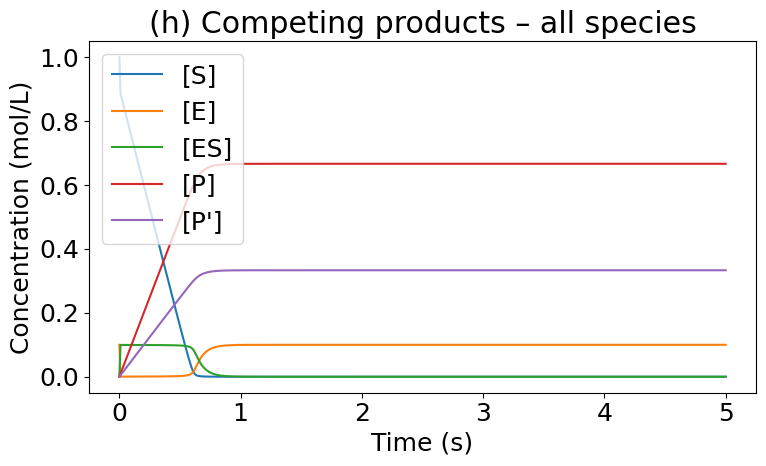

In [ ]:
kcat1 = 10.0          # 1/s  
kcat2 = 5.0           # 1/s   
E0 = 0.1              # mol/L
S0 = 1                # mol/L   
P0 = ES0 = P0c = 0    # mol/L 
kf = 1e4              # L/(mol·s)
kb = 20               # 1/s                    
   
# ODE system for competitive reaction
def ode_competing(t, y, kf, kb, kcat1, kcat2):
    S, E, ES, P, Pp = y
    dS  = -kf*S*E + kb*ES
    dE  = -kf*S*E + kb*ES + (kcat1+kcat2)*ES
    dES =  kf*S*E - kb*ES - (kcat1+kcat2)*ES
    dP  =  kcat1 * ES
    dPc =  kcat2 * ES
    return [dS, dE, dES, dP, dPc]


y0_comp = [S0, E0, ES0, P0, P0c]
t_span = [0,5]
sol_comp = solve_ivp(ode_competing, t_span, y0_comp,
                     args=(kf, kb, kcat1, kcat2),
                     t_eval=np.linspace(0, 5, 500), method='Radau', rtol=1e-8, atol=1e-10)

S_c, E_c, ES_c, P_c, Pp_c = sol_comp.y


# Plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(sol_comp.t, S_c,  label='[S]')
ax.plot(sol_comp.t, E_c,  label='[E]')
ax.plot(sol_comp.t, ES_c, label='[ES]')
ax.plot(sol_comp.t, P_c,  label='[P]')
ax.plot(sol_comp.t, Pp_c, label="[P']")
ax.set_xlabel('Time (s)'); ax.set_ylabel('Concentration (mol/L)')
ax.set_title('(h) Competing products - all species')
ax.legend()
plt.tight_layout()
plt.savefig('h_competing.png', dpi=150)
plt.show()

## Part (i) – Improving Selectivity

Both P and P' are formed from the **same intermediate ES**, so selectivity is:
$$\sigma_P = \frac{k_{cat1}}{k_{cat1} + k_{cat2}}$$

This is **independent of k₁, k₋₁, [S], and [E₀]**. The only way to improve selectivity is:

1. **Increase k_cat1** – engineer the enzyme to catalyse the desired reaction faster.
2. **Decrease k_cat2** – engineer the enzyme to suppress the side reaction.

Neither k₁ nor k₋₁ (nor [E₀]) affect selectivity because the ratio P:P' is set entirely by the branching at the ES node.

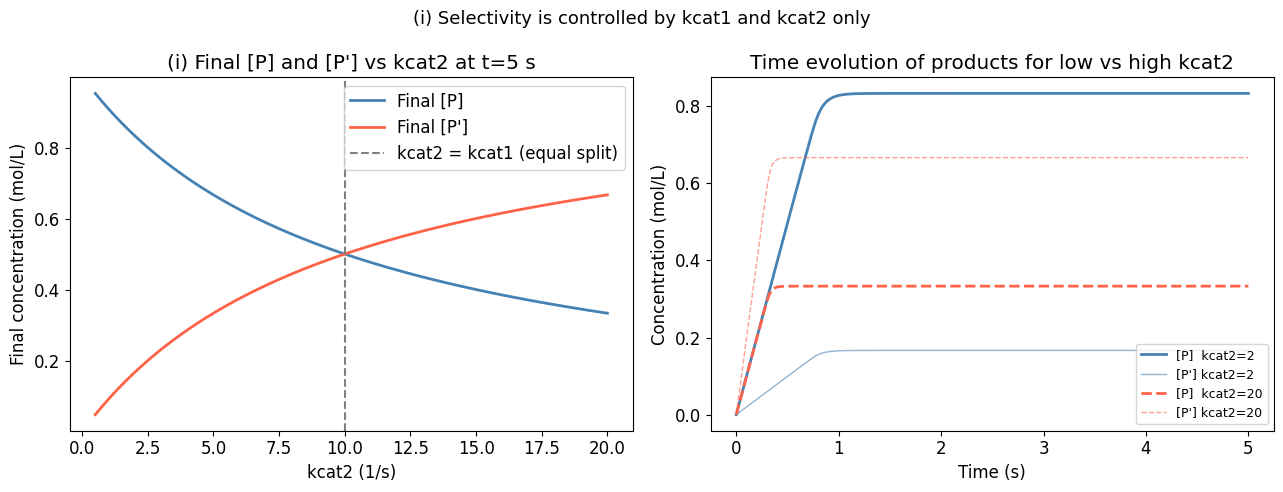

Key insight: σ_P = kcat1/(kcat1+kcat2) is a constant — it does not vary with
time, [S], k1, or km1. To improve selectivity toward P you must either
increase kcat1 or decrease kcat2 (i.e. engineer the enzyme active site).


In [ ]:
# Note: selectivity σ = kcat1/(kcat1+kcat2) is a CONSTANT — independent of time,
# [S], k1, and km1. So a time-series selectivity plot just gives flat lines.
# Instead we show:
#   Left panel : final [P] and [P'] at t=5 s as a function of kcat2
#   Right panel: time evolution of [P] and [P'] for two extreme kcat2 cases

kcat2_sweep = np.linspace(0.5, 20, 80)
final_P, final_Pp = [], []

for kc2 in kcat2_sweep:
    sol_i = solve_ivp(ode_competing, t_span, y0_comp,
                      args=(kf, kb, kcat1, kc2),
                      t_eval=[5.0], method='Radau', rtol=1e-8, atol=1e-10)
    final_P.append(sol_i.y[3, -1])
    final_Pp.append(sol_i.y[4, -1])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: final yields vs kcat2
axes[0].plot(kcat2_sweep, final_P,  label='Final [P]',  color='steelblue', lw=2)
axes[0].plot(kcat2_sweep, final_Pp, label="Final [P']", color='tomato',    lw=2)
axes[0].axvline(kcat1, color='gray', ls='--', label='kcat2 = kcat1 (equal split)')
axes[0].set_xlabel('kcat2 (1/s)')
axes[0].set_ylabel('Final concentration (mol/L)')
axes[0].set_title('(i) Final [P] and [P\'] vs kcat2 at t=5 s')
axes[0].legend()

# Right: time evolution for kcat2=2 (selective) vs kcat2=20 (unselective)
colors = {'kcat2=2': 'steelblue', 'kcat2=20': 'tomato'}
for kc2, ls in [(2, '-'), (20, '--')]:
    sol_i = solve_ivp(ode_competing, t_span, y0_comp,
                      args=(kf, kb, kcat1, kc2),
                      t_eval=t_eval, method='BDF', rtol=1e-8, atol=1e-10)
    c = 'steelblue' if kc2 == 2 else 'tomato'
    axes[1].plot(sol_i.t, sol_i.y[3], color=c, ls=ls,       lw=2, label=f'[P]  kcat2={kc2}')
    axes[1].plot(sol_i.t, sol_i.y[4], color=c, ls=ls, lw=1, alpha=0.6, label=f"[P'] kcat2={kc2}")

axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Concentration (mol/L)')
axes[1].set_title('Time evolution of products for low vs high kcat2')
axes[1].legend(fontsize=9)

plt.suptitle('(i) Selectivity is controlled by kcat1 and kcat2 only', fontsize=13)
plt.tight_layout()
plt.savefig('i_selectivity.png', dpi=150)
plt.show()

print('Key insight: σ_P = kcat1/(kcat1+kcat2) is a constant — it does not vary with')
print('time, [S], k1, or km1. To improve selectivity toward P you must either')
print('increase kcat1 or decrease kcat2 (i.e. engineer the enzyme active site).')